<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# ICS40125 - Laboratorio N°02

**Objetivos del Laboratorio 2**

* Reforzar el uso de la librería **NumPy** para el manejo y procesamiento eficiente de datos numéricos.
* Aplicar operaciones vectorizadas y funciones matemáticas de NumPy en contextos reales.
* Comprender la implementación de un modelo de **regresión lineal simple** utilizando arrays de NumPy.
* Interpretar los resultados obtenidos a partir del modelo ajustado.



## Problema 01 — Introducción a la regresión lineal simple

El objetivo de este laboratorio es implementar y analizar un modelo de **regresión lineal simple**, utilizando operaciones vectorizadas con **NumPy**.

### Definición general

El modelo de **regresión lineal múltiple** se expresa como:

$$
\boldsymbol{Y} = \boldsymbol{X} \boldsymbol{\beta} + \boldsymbol{\epsilon}
$$

donde:

* $\boldsymbol{X} = (x_1, \dots, x_n)^\top$: variable explicativa (matriz de diseño).
* $\boldsymbol{Y} = (y_1, \dots, y_n)^\top$: variable respuesta.
* $\boldsymbol{\epsilon} = (\epsilon_1, \dots, \epsilon_n)^\top$: término de error, asumido como ruido blanco: $\epsilon \sim \mathcal{N}(0, \sigma^2 I)$.
* $\boldsymbol{\beta} = (\beta_0, \beta_1, \dots, \beta_p)^\top$: coeficientes del modelo.

En el caso particular de la **regresión lineal simple**, se modela una única variable explicativa $x$ y una respuesta $y$, mediante la relación:

$$
y_i = \beta_0 + \beta_1 x_i + \epsilon_i
$$

El objetivo es encontrar los valores de $\beta_0$ y $\beta_1$ que ajusten una recta a los datos observados, minimizando la diferencia entre los valores reales $y_i$ y los valores predichos $\hat{y}_i$.

<div align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/3/3a/Linear_regression.svg" width="500"/>
</div>


### ¿Cuándo un modelo lineal no es adecuado?

Existen situaciones en las que los modelos lineales no entregan buenos resultados, por ejemplo:

* Cuando el rango de valores de $Y$ está restringido (como en variables binarias o de conteo).
* Cuando la varianza de $Y$ no es constante y depende de su media (heterocedasticidad).




### Estimación de parámetros: Método de mínimos cuadrados

El **método de mínimos cuadrados** es una técnica de optimización que permite encontrar los parámetros que mejor ajustan un modelo a los datos, minimizando la suma de los errores al cuadrado. Formalmente, el problema consiste en resolver:

$$
(P) \quad \min \sum_{i=1}^n e_i^2 = \sum_{i=1}^n (y_i - f_i(x; \beta))^2
$$

En el caso de la **regresión lineal simple**, se busca ajustar una función de la forma:

$$
f(x; \beta) = \beta_0 + \beta_1 x
$$

Por lo tanto, el problema de optimización se convierte en:

$$
(P) \quad \min \sum_{i=1}^n \left( y_i - (\beta_0 + \beta_1 x_i) \right)^2
$$

El objetivo es encontrar los coeficientes $\beta = (\beta_0, \beta_1)$ que minimicen esta suma.

La solución analítica del problema se obtiene a partir de derivadas parciales y está dada por:

$$
\hat{\beta}_1 = \dfrac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}
\quad , \quad
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$$

La pendiente $\hat{\beta}_1$ también puede interpretarse como la correlación lineal escalada entre $x$ y $y$.






### Selección de modelos — Coeficiente de determinación ($R^2$)

El [coeficiente de determinación](https://en.wikipedia.org/wiki/Coefficient_of_determination), comúnmente conocido como **$R^2$**, es un estadístico utilizado para evaluar la calidad de ajuste de un modelo estadístico, especialmente en regresión lineal.

Su principal propósito es medir qué tan bien el modelo logra explicar la variabilidad observada en la variable respuesta. Es decir, indica la **proporción de la variación total de $y$** que puede ser explicada por el modelo.

El valor de $R^2$ está acotado entre 0 y 1:

* Un valor cercano a **0** sugiere que el modelo **no explica bien los datos**.
* Un valor cercano a **1** indica que el modelo **ajusta muy bien los datos** observados.



### Fórmula

$$
R^2 = \dfrac{SS_{\text{reg}}}{SS_{\text{tot}}} = 1 - \dfrac{SS_{\text{res}}}{SS_{\text{tot}}}
$$

donde:

* $SS_{\text{reg}}$: **Suma de cuadrados explicada (ESS)**

  $$
  SS_{\text{reg}} = \sum_{i=1}^n (\hat{y}_i - \bar{y})^2
  $$

* $SS_{\text{res}}$: **Suma de cuadrados residual (RSS)**

  $$
  SS_{\text{res}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \sum_{i=1}^n e_i^2
  $$

* $SS_{\text{tot}}$: **Suma total de cuadrados (TSS)**

  $$
  SS_{\text{tot}} = \sum_{i=1}^n (y_i - \bar{y})^2
  $$

Se cumple que:

$$
SS_{\text{tot}} = SS_{\text{reg}} + SS_{\text{res}}
$$



### Interpretación

El coeficiente $R^2$ está relacionado con la **fracción de varianza no explicada** (FVU). Cuanto menor sea el error residual (RSS), mayor será $R^2$, y mejor será el ajuste del modelo.



<div align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/86/Coefficient_of_Determination.svg/600px-Coefficient_of_Determination.svg.png" width="500"/>
</div>

* Las áreas **azules** representan los residuos al cuadrado respecto a la **media** ($SS_{\text{tot}}$).
* Las áreas **rojas** representan los residuos al cuadrado respecto a la **regresión** ($SS_{\text{res}}$).




Claro, aquí tienes una versión mejorada del texto sobre el **error del modelo**, con redacción más clara, precisión conceptual, ortografía corregida y mejor organización visual:



## Evaluación del error en un modelo

### Definición

El **error** de un modelo corresponde a la diferencia entre el valor real observado y el valor estimado por el modelo. Se define como:

$$
e_i = y_i - \hat{y}_i
$$

donde $y_i$ es el valor real y $\hat{y}_i$ el valor predicho para el dato $i$.

<div align="center">
<img src="https://allmodelsarewrong.github.io/images/ols/ols-geom-obs3.svg" width="500"/>
</div>



### ¿Cómo se mide el error?

Para evaluar qué tan bien se ajusta un modelo a los datos, se utilizan **métricas de error** o **funciones de pérdida**. Estas métricas cuantifican el grado de desviación entre las predicciones y los valores reales. A continuación se presentan las más comunes, divididas en dos categorías:



### 1. Métricas absolutas

Las métricas absolutas miden el error en la misma escala que los datos, sin realizar normalización. Son útiles cuando la escala del problema es conocida y relevante.

* **Error absoluto medio (MAE)**

$$
\text{MAE}(y, \hat{y}) = \dfrac{1}{n} \sum_{t=1}^{n} \left| y_t - \hat{y}_t \right|
$$

* **Error cuadrático medio (MSE)**

$$
\text{MSE}(y, \hat{y}) = \dfrac{1}{n} \sum_{t=1}^{n} \left( y_t - \hat{y}_t \right)^2
$$

Estas métricas penalizan los errores de distinta forma: el MSE penaliza más los errores grandes, mientras que el MAE es más robusto ante valores atípicos.



### 2. Métricas porcentuales

Las métricas porcentuales escalan el error en relación al valor real, permitiendo comparar modelos o datos en distintas unidades o magnitudes. Aunque están acotadas en teoría entre 0 y 1, en la práctica pueden superar el 1 (especialmente cuando los valores reales son pequeños).

* **Error porcentual absoluto medio (MAPE)**

$$
\text{MAPE}(y, \hat{y}) = \dfrac{1}{n} \sum_{t=1}^{n} \left| \frac{y_t - \hat{y}_t}{y_t} \right|
$$

* **Error porcentual absoluto medio simétrico (sMAPE)**

$$
\text{sMAPE}(y, \hat{y}) = \dfrac{1}{n} \sum_{t=1}^{n} \frac{\left| y_t - \hat{y}_t \right|}{\left( \left| y_t \right| + \left| \hat{y}_t \right| \right)/2}
$$

> Nota: El sMAPE evita algunos problemas del MAPE cuando los valores reales se acercan a cero.








## Problema a resolver

En este ejercicio trabajaremos con un conjunto de datos que relaciona los **años de experiencia laboral** con el **salario anual** de distintas personas.

El objetivo es construir un modelo de **regresión lineal simple** que permita predecir el salario en función de los años de experiencia, y utilizar **NumPy** para realizar todas las operaciones necesarias.

El conjunto de datos contiene dos columnas:

* `YearsExperience`: cantidad de años de experiencia laboral (variable explicativa o independiente).
* `Salary`: salario anual (variable de respuesta o dependiente).

A continuación, se presenta explícitamente el conjunto de datos.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

YearsExperience = np.array([
 1.1,1.3,1.5,2.0,2.2,
 2.9,3.0,3.2,3.2,3.7,
 3.9,4.0,4.0,4.1,4.5,
 4.9,5.1,5.3,5.9,6.0,
 6.8,7.1,7.9,8.2,8.7,
 9.0,9.5,9.6,10.3,10.5
 ])

Salary =  np.array([
 39343.0,46205.0,37731.0,43525.0,39891.0,
 56642.0,60150.0,54445.0,64445.0,57189.0,
 63218.0,55794.0,56957.0,57081.0,61111.0,
 67938.0,66029.0,83088.0,81363.0,93940.0,
 91738.0,98273.0,101302.0,113812.0,109431.0,
 105582.0,116969.0,112635.0,122391.0,121872.0
])



Nuestro objetivo es encontrar un modelo de **regresión lineal simple** que relacione el salario con los años de experiencia. El modelo a ajustar tiene la siguiente forma:

$$
Salary_i = \beta_0 + \beta_1 \cdot YearsExperience_i + \epsilon_i
$$

donde:

* $Salary_i$ es el salario observado para la persona $i$,
* $YearsExperience_i$ representa los años de experiencia,
* $\beta_0$ es el intercepto del modelo,
* $\beta_1$ es la pendiente o coeficiente de regresión, y
* $\epsilon_i$ es el error aleatorio asociado a la observación $i$.

A continuación, deberás resolver las siguientes preguntas para construir, ajustar y evaluar el modelo utilizando **NumPy**.



**1. Estimación de coeficientes**

Define una función llamada `estimate_coef(x, y)` que reciba dos arreglos de NumPy:

* `x`: variable explicativa (años de experiencia),
* `y`: variable de respuesta (salario),

y retorne una tupla con los coeficientes estimados de la regresión lineal simple $(b_0, b_1)$, donde:

$$
b_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \quad
b_0 = \bar{y} - b_1 \cdot \bar{x}
$$


In [7]:
def estimate_coef(x, y):
    """
    Encontrar los coeficientes del modelo de
    regresion lineal: beta = (beta_0,beta_1)
    """
    # number of observations/points
    n = np.size(x)

    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x

    # calculating regression coefficients
    beta_1 = SS_xy / SS_xx
    beta_0 = m_y - beta_1*m_x

    return (beta_0, beta_1)

In [11]:
# imprimir valores del beta estimado
beta_estimado = estimate_coef(YearsExperience, Salary)
print(f"Coeficientes estimados:\nb_0 = {beta_estimado[0]:.4f} \nb_1 = {beta_estimado[1]:.4f}")

Coeficientes estimados:
b_0 = 25792.2002 
b_1 = 9449.9623




**2. Visualización del modelo ajustado**

Utiliza la función `plot_regression_line(x, y, yhat)` para graficar los datos observados junto con la recta de regresión obtenida.

* `x`: valores de la variable explicativa (años de experiencia),
* `y`: valores observados de la variable de respuesta (salario),
* `yhat`: valores predichos por el modelo lineal, calculados como $\hat{y} = b_0 + b_1 x$

La gráfica debe incluir:

* Un diagrama de dispersión con los puntos observados $(x_i, y_i)$,
* La recta de regresión que representa el modelo ajustado.



In [12]:
def plot_regression_line(x, y, yhat):
    plt.figure(figsize=(10,4))
    # plotting the actual points as scatter plot
    plt.scatter(x, y, color = "m",marker = "o", s = 30)


    # plotting the regression line
    plt.plot(x, yhat, color = "g")

    # putting labels
    plt.xlabel('YearsExperience')
    plt.ylabel('Salary')
    plt.title("Plot YearsExperience vs Salary")

    # function to show plot
    plt.show()

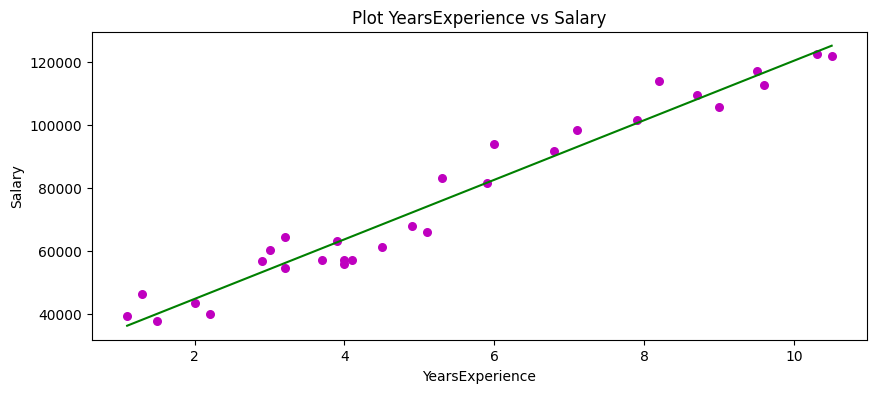

In [13]:
# mostrar resultados del ajuste lineal
prediccion = beta_estimado[0] + beta_estimado[1]*YearsExperience
plot_regression_line(YearsExperience, Salary, prediccion)



**3. Evaluación cuantitativa del modelo**

Utiliza los valores reales (`y`) y los valores predichos por el modelo (`yhat`) para calcular diversas métricas que cuantifican el error y la calidad del ajuste.

Debes definir e implementar las siguientes funciones:

* `mae(y, yhat)`: **Error absoluto medio**

  $$
  \text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|
  $$

* `rmse(y, yhat)`: **Raíz del error cuadrático medio**

  $$
  \text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2 }
  $$

* `mape(y, yhat)`: **Error porcentual absoluto medio**

  $$
  \text{MAPE} = \frac{1}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|
  $$

* `smape(y, yhat)`: **Error porcentual absoluto medio simétrico**

  $$
  \text{sMAPE} = \frac{1}{n} \sum_{i=1}^n \frac{ |y_i - \hat{y}_i| }{ (|y_i| + |\hat{y}_i|)/2 }
  $$

* `rsquared(y, yhat)`: **Coeficiente de determinación $R^2$**

  $$
  R^2 = 1 - \frac{ \sum_{i=1}^n (y_i - \hat{y}_i)^2 }{ \sum_{i=1}^n (y_i - \bar{y})^2 }
  $$


In [14]:
def mae(y, yhat) -> float:
    """
    Calculo de la metrica: mean absolute error (MAE)
    """
    metrica = np.mean(np.abs(y - yhat))
    return metrica

In [15]:
def rmse(y, yhat) -> float:
    """
    Calculo de la metrica: root mean squared error (RMSE)
    """
    metrica = np.sqrt(np.mean((y - yhat)**2))
    return metrica

In [16]:
def mape(y, yhat) -> float:
    """
    Calculo de la metrica: mean absolute percentage error (MAPE)
    """
    # Evitar division por cero
    metrica = np.mean(np.abs((y - yhat) / y)) * 100 # Multiplicar por 100 para obtener porcentaje
    return metrica

In [17]:
def smape(y, yhat) -> float:
    """
    Calculo de la metrica: symmetric mean absolute percentage error (SMAPE)
    """
    # Evitar division por cero en el denominador
    numerator = np.abs(y - yhat)
    denominator = (np.abs(y) + np.abs(yhat)) / 2
    # Handle cases where denominator is zero to avoid NaN or Inf
    metrica = np.mean(np.where(denominator == 0, 0, numerator / denominator)) * 100
    return metrica

In [18]:
def rsquared(y, yhat) -> float:
    """
    Calculo del r-cuadrado
    """
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    metrica = 1 - (ss_res / ss_tot)
    return metrica

In [19]:
# calcular resultados
calcular_mae = round(mae(Salary,prediccion), 4)
calcular_rmse = round(rmse(Salary,prediccion), 4)
calcular_mape = round(mape(Salary,prediccion), 4)
calcular_smape = round(smape(Salary,prediccion), 4)
calcular_rsquared = round(rsquared(Salary,prediccion), 4)

In [20]:
# imprimir resultados
print(f"mae:   {calcular_mae}")
print(f"rmse:  {calcular_rmse}")
print(f"mape:  {calcular_mape}")
print(f"smape: {calcular_smape}")
print(f"r^2:   {calcular_rsquared}")

mae:   4644.2013
rmse:  5592.0436
mape:  7.048
smape: 7.0367
r^2:   0.957



**4. Análisis de resultados y conclusiones**

Con base en las métricas obtenidas, realiza una reflexión final sobre el desempeño del modelo.
Evalúa si la **regresión lineal simple** proporciona un buen ajuste para los datos observados. Para ello, considera lo siguiente:

* ¿El valor de $R^2$ indica una alta capacidad explicativa del modelo?
* ¿Los errores (MAE, RMSE, MAPE, sMAPE) son bajos en relación al rango de los salarios?
* ¿Hay patrones evidentes en los errores que sugieran que un modelo lineal no es adecuado?

Redacta tus conclusiones de forma clara, justificando si el modelo de regresión lineal es apropiado o si podrían considerarse otras alternativas.


**Respuesta**:

Aquí están los resultados de las métricas:

*   **MAE (Error Absoluto Medio):** 4644.2013
*   **RMSE (Raíz del Error Cuadrático Medio):** 5592.0436
*   **MAPE (Error Porcentual Absoluto Medio):** 7.048%
*   **sMAPE (Error Porcentual Absoluto Medio Simétrico):** 7.0367%
*   **R² (Coeficiente de Determinación):** 0.957

### Análisis de Resultados y Conclusiones

1.  **¿El valor de $R^2$ indica una alta capacidad explicativa del modelo?**
    *   Sí, un valor de $R^2$ de **0.957 es muy alto** (cercano a 1). Esto significa que aproximadamente el 95.7% de la variabilidad en el salario puede ser explicada por los años de experiencia, según nuestro modelo lineal. Este resultado sugiere una **fuerte relación lineal** entre las variables y una excelente capacidad explicativa del modelo.

2.  **¿Los errores (MAE, RMSE, MAPE, sMAPE) son bajos en relación al rango de los salarios?**
    *   El rango de salarios en nuestros datos va aproximadamente desde 37,000 hasta 122,000. Considerando este rango:
        *   El **MAE** de 4644.20 indica que, en promedio, la predicción del salario se desvía en unos 4,644 unidades monetarias del valor real. Esta cifra es razonable en el contexto de salarios que superan las 30,000 unidades.
        *   El **RMSE** (5592.04) es ligeramente superior al MAE, lo cual es esperable ya que el RMSE penaliza más los errores grandes. Sigue siendo un valor aceptable.
        *   Los valores de **MAPE** (7.048%) y **sMAPE** (7.0367%) son **relativamente bajos**. Un error porcentual promedio de alrededor del 7% indica que el modelo es bastante preciso, lo que es generalmente considerado un buen rendimiento para la predicción de salarios.

3.  **¿Hay patrones evidentes en los errores que sugieran que un modelo lineal no es adecuado?**
    *   Basándonos únicamente en estas métricas agregadas, no hay una señal clara de que un modelo lineal no sea adecuado. Los errores porcentuales son bajos y el $R^2$ es muy alto. Sin embargo, para una evaluación más profunda, sería ideal **inspeccionar visualmente los residuos** (la diferencia entre $y$ y $\hat{y}$) contra los valores predichos o la variable explicativa. Si los residuos muestran un patrón (por ejemplo, forma de "U", cono, etc.), podría indicar que la suposición de linealidad no se cumple perfectamente, o que la varianza no es constante (heterocedasticidad).

### Conclusión General

El modelo de **regresión lineal simple** parece ser **muy apropiado y efectivo** para predecir el salario en función de los años de experiencia en este conjunto de datos. El alto coeficiente de determinación ($R^2$) y los bajos errores absolutos y porcentuales sugieren que el modelo captura una parte significativa y consistente de la relación entre las variables.

Para este problema, la regresión lineal ofrece una solución robusta y con un buen poder predictivo. Si bien un análisis de residuos podría ofrecer más detalles sobre la distribución del error, los indicadores actuales validan la elección de un modelo lineal para esta tarea.